In [27]:
from src.OLS import OLS
from src.stat_tests import RESET, VIF, AR1, COOKS_D, CHOW, WALD

import pandas as pd
import numpy as np
np.set_printoptions(suppress=True, precision=6)

from scipy.stats import norm, t as t_dist
from statsmodels.graphics.tsaplots import plot_ccf

import matplotlib.pyplot as plt
import matplotlib as mpl

# mpl.rcParams['figure.dpi'] = 300 # uncomment when outputting figures for the paper
A4P = (8.27, 11.69)
A4L = (11.69, 8.27)

In [28]:
data_kw = {'encoding': 'utf-8', 'low_memory': False}

rgdp = pd.read_csv('data/fred/GDPC1.csv', **data_kw)
rgdp = rgdp.set_index('observation_date').rename(columns={'GDPC1': 'Y'})
rgdp.index = pd.to_datetime(rgdp.index)

pce = pd.read_csv('data/fred/PCECC96.csv', **data_kw)
pce = pce.set_index('observation_date').rename(columns={'PCECC96': 'pce'})
pce.index = pd.to_datetime(pce.index)
pce = pce.loc[rgdp.index]

pdi = pd.read_csv('data/fred/GPDIC1.csv', **data_kw)
pdi = pdi.set_index('observation_date').rename(columns={'GPDIC1': 'pdi'})
pdi.index = pd.to_datetime(pdi.index)
pdi = pdi.loc[rgdp.index]

govexp = pd.read_csv('data/fred/GCEC1.csv', **data_kw)
govexp = govexp.set_index('observation_date').rename(columns={'GCEC1': 'govexp'})
govexp.index = pd.to_datetime(govexp.index)
govexp = govexp.loc[rgdp.index]

odef = pd.read_csv('data/fred/GDPDEF.csv', **data_kw)
odef = odef.set_index('observation_date').rename(columns={'GDPDEF': 'odef'})
odef.index = pd.to_datetime(odef.index)
odef = odef.loc[rgdp.index]

unat = pd.read_csv('data/fred/NROU.csv', **data_kw)
unat = unat.set_index('observation_date').rename(columns={'NROU': 'u^*'})
unat.index = pd.to_datetime(unat.index)
unat = unat.loc[rgdp.index]

unrate = pd.read_csv('data/fred/LRUN64TTUSQ156S.csv', **data_kw)
unrate = unrate.set_index('observation_date').rename(columns={'LRUN64TTUSQ156S': 'u'})
unrate.index = pd.to_datetime(unrate.index)
unrate = unrate.loc[rgdp.index]

ugap = pd.DataFrame(
    {
    "ugap": unrate['u'] - unat['u^*']
    })
# ugap = ugap - ugap.mean()

gdp_pot = pd.read_csv('data/fred/GDPPOT.csv', **data_kw)
gdp_pot = gdp_pot.set_index('observation_date').rename(columns={'GDPPOT': 'Y^*'})
gdp_pot.index = pd.to_datetime(gdp_pot.index)
gdp_pot = gdp_pot.loc[rgdp.index]

ogap = pd.DataFrame({
    "ogap": np.log(rgdp['Y']) - np.log(gdp_pot['Y^*']),
})
# ogap = ogap - ogap.mean()

netexp = pd.read_csv('data/fred/NETEXP.csv', **data_kw)
netexp = netexp.set_index('observation_date').rename(columns={'NETEXP': 'NETEXP'})
netexp.index = pd.to_datetime(netexp.index)
netexp = netexp.loc[rgdp.index]
netexp['NETEXP'] = netexp['NETEXP'] / rgdp['Y']
# Interactions
okun = pd.DataFrame({
    "okun": ugap['ugap'] * ogap['ogap'],
})

phillips = pd.DataFrame({
    "phillips": ugap['ugap'] * np.log(odef['odef']).diff(),
})

shock_dates = (
    # pd.Timestamp("2020-07-01"),
    # pd.Timestamp("2020-04-01"),
    pd.Timestamp("2008-10-01"),
)

In [29]:
target = np.log(rgdp).diff().dropna() * 100
fmt_regressors = [
    np.log(pce).diff().loc[target.index],
    np.log(pdi).diff().loc[target.index],
    np.log(govexp).diff().loc[target.index],
    # np.log(odef).diff().loc[target.index],
    ugap.loc[target.index].diff(),
    ogap.loc[target.index],

    okun.loc[target.index],    
    phillips.loc[target.index],
]
X = pd.concat(fmt_regressors, axis=1).shift(1).dropna()
t_idx = X.index
# shock_idx = [t_idx.get_loc(date) for date in shock_dates if date in t_idx]

# dummies = []
# for i, date in enumerate(shock_dates):
#     dummy = pd.Series(0, index=t_idx)
#     dummy.loc[date] = 1
#     dummy.name = f"dummy_{i+1}"
#     dummies.append(dummy)
# X = pd.concat([X] + dummies, axis=1)
t_idx = t_idx[:-21]\
    # .where(~t_idx[:-21].isin(shock_dates)).dropna()

X = X.loc[t_idx]
y = target.loc[t_idx]

In [30]:
fit = OLS(
    X=X.values,
    y=y.values.flatten(),
).fit(diagnosis_alpha=0.05, diagnosis_trend='n')
fit.error

R2: 0.3955
R2_ADJ: 0.3507
RMSE: 0.4525
MAPE: 0.7409

In [31]:
VIF(X)

array([1.470508, 1.750083, 1.568646, 2.246408, 3.733865, 2.52754 ,
       2.839916])

In [32]:
RESET(
    X=X,
    y=y.values.flatten(),
    q=2
)

reject: True
pval: 0.01669962106157241
test_stat: 4.25295616484152
stat_name: RESET Test (F-Statistic)

In [33]:
t = {'_const': fit.T_tests[0]}
for i, var in enumerate(X.columns):
    t[var] = fit.T_tests[i+1]
{k: round(v.pval, 4) for k, v in t.items()}

{'_const': 0.0528,
 'pce': 0.0,
 'pdi': 0.019,
 'govexp': 0.1622,
 'ugap': 0.5661,
 'ogap': 0.0043,
 'okun': 0.9322,
 'phillips': 0.0015}

In [53]:
fit.intercept.round(4), fit.coefs.round(4).astype(float)

(np.float64(0.1934),
 array([ 63.5334,   4.5738, -10.7911,  -0.1312, -13.8038,  -0.1075,
        -32.7953]))

In [35]:
fit.F_test

reject: True
pval: 3.085861899343456e-09
test_stat: 8.832903769654923
stat_name: F Test (F-Statistic)

In [36]:
fit.XT_e

np.float64(5.299886506222873e-14)

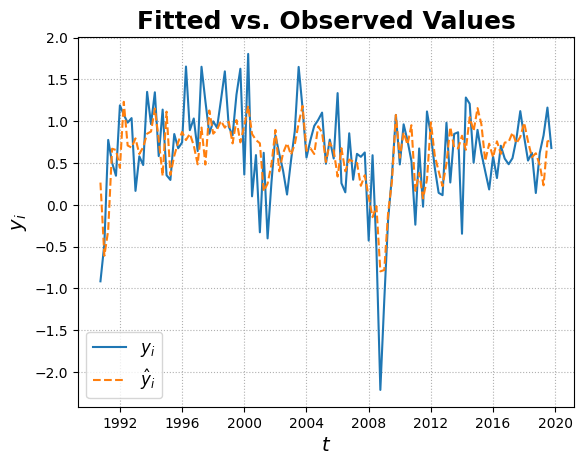

In [37]:
plt.plot(t_idx, y, label=r"$y_i$")
plt.plot(t_idx, fit.fitted_values, label=r"$\hat{y}_i$", linestyle='--')


plt.title(r"Fitted vs. Observed Values", fontsize=18, weight='bold')
plt.grid(alpha=1, linestyle=":")
plt.tick_params(axis="x", rotation=0, labelsize=10)
plt.tick_params(axis="y", rotation=0, labelsize=10)

plt.ylabel(r"$y_i$", fontsize=14)
plt.xlabel(r"$t$", fontsize=14)

plt.legend(fontsize=12)
# plt.savefig('paper2/fig/fit_v_obs.png', dpi=300)
plt.show()

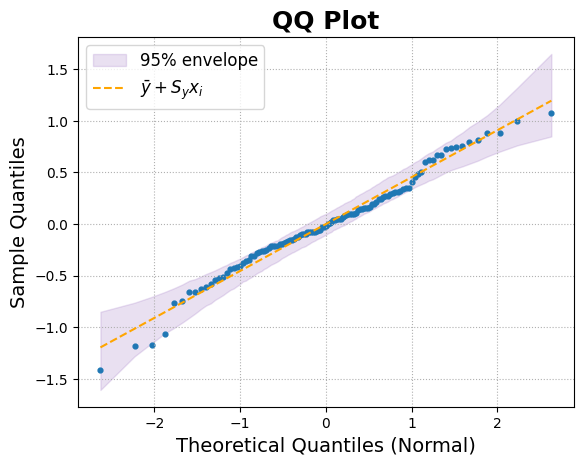

reject: False
pval: 0.09743060037973372
test_stat: 0.981049656408501
stat_name: Shapiro-Wilk Test (Approximated Z-Statistic)

In [38]:
fit.qq(line='45')
fit.resid_normality

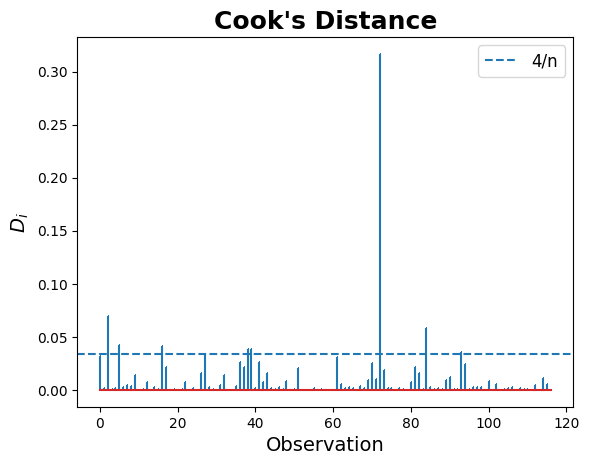

DatetimeIndex(['1991-04-01', '1992-01-01', '1994-10-01', '1997-07-01',
               '2000-04-01', '2000-07-01', '2008-10-01', '2011-10-01',
               '2014-01-01'],
              dtype='datetime64[ns]', name='observation_date', freq=None)

In [41]:
D, *_ = COOKS_D(
    X=X,
    y=y.values.flatten(),
    intercept=True,
    plot=True
)

obs = np.where(D > 4/len(t_idx))
t_idx[obs]

In [42]:
fit.resid_normality

reject: False
pval: 0.09743060037973372
test_stat: 0.981049656408501
stat_name: Shapiro-Wilk Test (Approximated Z-Statistic)

In [43]:
fit.resid_heteroske

reject: False
pval: 0.9775275358819676
test_stat: 16.304861381087385
stat_name: Breusch-Pagan Test (Chi^2 Statistic)

In [44]:
fit.resid_autocorr[-2:]

[reject: False
 pval: 0.367149758070307
 test_stat: 5.2223410899620335
 stat_name: BG(7) Test (Chi^2 Statistic),
 reject: False
 pval: 0.28120164942339
 test_stat: 5.357255294017326
 stat_name: BG(8) Test (Chi^2 Statistic)]

In [45]:
fit.resid_stationarity

reject: True
pval: 0.0037303660002659944
test_stat: -2.8939198638577603
stat_name: ADF Test (T-Statistic)

In [46]:
np.linalg.cond(X)

np.float64(72.44071577984306)